In [1]:
import matplotlib.pyplot as plt
import scienceplots

plt.style.use('science')

import numpy as np

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

from pycbc.psd.analytical import aLIGO140MpcT1800545

PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


In [2]:
import sys
sys.path.insert(1, '../../detectability')

import resonance
from resonance import Filter, phase_diff_t_shift, phase_shift #System, 

In [3]:
import os

figures_path = '../figures/I'
os.makedirs(figures_path, exist_ok=True) 

In [4]:
f_low, f_high, tlen, srate, dL, approximant, detector = [15, 1024, 4, 2*1024, 100, 'IMRPhenomD', 'aLIGO/Asharp_strain']

filt = Filter(f_low, f_high, tlen, srate, dL, approximant, detector)

/home/alberto/ns-resonance/jupyter-env/lib/python3.12/site-packages/pycbc/types/array.py:390: RuntimeWarning: divide by zero encountered in divide
  return self._data.__rtruediv__(other)


In [5]:
frequency_colors = {50: 'blue', 100: 'green', 150: 'orange'}

In [6]:
def match_plot(fres, dPsi, dx_arr, color):
    match_PyCBC_arr, match_approx_arr = filt.match_dx(fres, dPsi, dx_arr)
    plt.plot(-dx_arr, match_PyCBC_arr, color=color, label=f'PyCBC. $f_{{res}}={fres}\,\\text{{Hz}}$')
    plt.plot(-dx_arr, match_approx_arr,'-.', color=color, label=f'Quad. $f_{{res}}={fres}\,\\text{{Hz}}$')

<>:3: SyntaxWarning: invalid escape sequence '\,'
<>:4: SyntaxWarning: invalid escape sequence '\,'
<>:3: SyntaxWarning: invalid escape sequence '\,'
<>:4: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_19193/651964891.py:3: SyntaxWarning: invalid escape sequence '\,'
  plt.plot(-dx_arr, match_PyCBC_arr, color=color, label=f'PyCBC. $f_{{res}}={fres}\,\\text{{Hz}}$')
/tmp/ipykernel_19193/651964891.py:4: SyntaxWarning: invalid escape sequence '\,'
  plt.plot(-dx_arr, match_approx_arr,'-.', color=color, label=f'Quad. $f_{{res}}={fres}\,\\text{{Hz}}$')


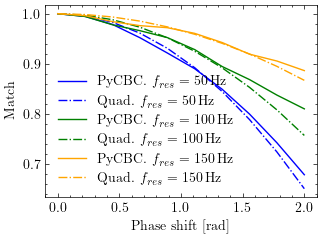

In [7]:
length_arr = 10
dphi_arr = -np.linspace(0., 2, length_arr)

plt.figure(figsize=(3.5, 2.5))
[match_plot(fres, phase_shift, dphi_arr, color) for fres, color in frequency_colors.items()]
#plt.yscale('log') 

#plt.title(f"Quadratic approximation validity. Phase shift")
plt.xlabel('Phase shift [rad]')
plt.ylabel('Match')
plt.legend()
plt.savefig(os.path.join(figures_path, f'approx_phase_shift.png'), bbox_inches='tight', dpi=300)
plt.show()

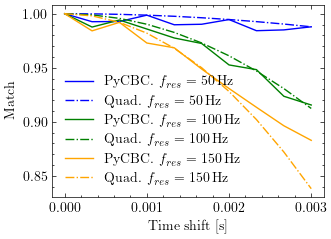

In [8]:
length_arr = 10
dt_arr = -np.linspace(0., 3, length_arr)*1e-3

plt.figure(figsize=(3.5, 2.5))
[match_plot(fres, phase_diff_t_shift, dt_arr, color) for fres, color in frequency_colors.items()]
#plt.yscale('log') 

#plt.title(f"Quadratic approximation validity. Time shift")
plt.xlabel('Time shift [s]')
plt.ylabel('Match')
plt.legend()
plt.savefig(os.path.join(figures_path, f'approx_time_shift.png'), bbox_inches='tight', dpi=300)
plt.show()